Build visits once(reviews + tips + business coords)

In [1]:
import pandas as pd

# =========================
# Load original business file
# =========================
biz = pd.read_csv("business_10k.csv")

print("Original businesses:", len(biz))

# =========================
# STRICT restaurant filter
# =========================
def is_restaurant(categories):
    """
    Yelp categories is a comma-separated string.
    We treat a business as a restaurant if 'Restaurants'
    appears anywhere in the category list.
    """
    if not isinstance(categories, str):
        return False
    return "restaurants" in categories.lower()

biz_rest = biz[biz["categories"].apply(is_restaurant)].copy()

print("🍽️ Restaurant-only businesses:", len(biz_rest))
print("📉 Removed:", len(biz) - len(biz_rest))

# =========================
# Sanity checks
# =========================
assert biz_rest["business_id"].isna().sum() == 0
assert biz_rest["latitude"].isna().sum() == 0
assert biz_rest["longitude"].isna().sum() == 0

print("✅ No missing business_id / lat / lon")

# =========================
# Save filtered file
# =========================
OUT_PATH = "business_10k_restaurants.csv"
biz_rest.to_csv(OUT_PATH, index=False)

print(f"✅ Saved restaurant-only file → {OUT_PATH}")

Original businesses: 23597
🍽️ Restaurant-only businesses: 14027
📉 Removed: 9570
✅ No missing business_id / lat / lon
✅ Saved restaurant-only file → business_10k_restaurants.csv


In [2]:
import pandas as pd

users   = pd.read_csv("users_10k.csv")
reviews = pd.read_csv("reviews_10k.csv")
tips    = pd.read_csv("tips_10k.csv")
biz     = pd.read_csv("business_10k_restaurants.csv")

# unify visits
reviews_ev = reviews[["user_id","business_id","date"]].copy()
reviews_ev["type"] = "review"

tips_ev = tips[["user_id","business_id","date"]].copy()
tips_ev["type"] = "tip"

visits = pd.concat([reviews_ev, tips_ev], ignore_index=True)

# attach lat/lon
visits = visits.merge(
    biz[["business_id","latitude","longitude"]],
    on="business_id",
    how="left"
).dropna(subset=["latitude","longitude"])

print("visits rows:", len(visits))
print("unique users:", visits["user_id"].nunique())

visits rows: 27732
unique users: 7393


In [3]:
print("visits users:", visits["user_id"].nunique())
print("users table:", users["user_id"].nunique())

missing_users = set(visits["user_id"]) - set(users["user_id"])
print("users in visits but not in users_10k:", len(missing_users))

visits users: 7393
users table: 10000
users in visits but not in users_10k: 0


Why only 7,393 users show up in visits?

Because 2,607 users (10,000 − 7,393) ended up with zero matched restaurant events after your filtering/merge. That can happen for a few reasons:

- They wrote reviews/tips, but not on businesses tagged “Restaurants”
(e.g., Shopping, Beauty, Nightlife without “Restaurants”, etc.)

- They didn’t write any reviews/tips in your extracted CSVs
(possible if the user exists in user sample but has no reviews/tips in your filtered files)

- Their reviewed/tipped businesses didn’t appear in business_10k_restaurants.csv
(coverage issue: business table missing some business_ids referenced by reviews/tips)

In [4]:
restaurant_biz_ids = set(biz["business_id"].astype(str))
visits_all = pd.concat([reviews_ev, tips_ev], ignore_index=True)
match_rate = visits_all["business_id"].astype(str).isin(restaurant_biz_ids).mean()
print("match rate to restaurant business table:", match_rate)

match rate to restaurant business table: 0.6857566765578635


In [5]:
users_with_any_activity = set(reviews["user_id"]).union(set(tips["user_id"]))
print("users with ANY review/tip:", len(users_with_any_activity))

missing_in_visits = set(users["user_id"]) - set(visits["user_id"])
missing_but_active = missing_in_visits.intersection(users_with_any_activity)
print("users missing in visits but had activity:", len(missing_but_active))

users with ANY review/tip: 10000
users missing in visits but had activity: 2607


Although 10,000 users were sampled, only 7,393 users had at least one geolocated restaurant visit after filtering. Users without restaurant visits were excluded from spatial clustering to ensure mobility patterns reflect dining behavior.

# Proper DBSCAN pipeline

For each user, we have a set of visited restaurant coordinates (lat/lon). DBSCAN will group those points into dense clusters:

- A cluster ≈ a “hub” (home area / work area / favourite area)

- Noise points (label = -1) ≈ “rare/random visits”

We then summarize:

- How many hubs each user has (1 hub vs 2 hubs vs many)

- How far apart the biggest two hubs are (home-work distance proxy)

- How wide the user travels overall (typical travel range)

In [8]:
import pandas as pd

visits = pd.read_csv("visits_restaurant_geolocated.csv")

# eligible user ids (one per line)
with open("eligible_users_restaurant.txt", "r", encoding="utf-8") as f:
    eligible = [line.strip() for line in f if line.strip()]

# if your file accidentally contains a header like "user_id", drop it
eligible = [u for u in eligible if u != "user_id"]

visits = visits[visits["user_id"].isin(set(eligible))].copy()

print("rows:", len(visits))
print("eligible users in visits:", visits["user_id"].nunique())
visits.head()

rows: 27732
eligible users in visits: 7393


,user_id,business_id,date,type,latitude,longitude
0,cpp89UW0imv45y3a_O444w,34Eqv8jXgxg_EEwcsNgeeg,2014-05-25 22:33:02,review,34.415114,-119.694497
1,MVuNw-mO5on8PpO_I6QtKg,o7cD_sDA-Evj3Oh0zeH9nQ,2015-03-18 18:28:22,review,39.477210,-119.764903
2,sHm9bRvQ2QFL7teGnHiGEA,LktIfbmd3k0kDiWibGw7DQ,2013-12-07 21:31:24,review,39.925490,-86.089045
3,Rhk8owk3uhFTvzJdYbQ6Xg,vje0KIiE7vtpx7JzmBx5LQ,2015-10-08 13:21:55,review,27.769405,-82.767317
4,H2WhI7u2Zc-ozPnKBvhWwQ,-hVMfjPPEsSnga_gnYJx2w,2007-12-08 19:17:57,review,39.487580,-119.759306


### Deciding a good eps_km

DBSCAN needs:

- eps = radius that defines “nearby”

- min_samples = minimum points needed to form a dense area

A standard way to choose eps is a k-distance elbow:

- compute distance to each point’s k-th nearest neighbour (k = min_samples)

- look for the “elbow” (where distances jump)

- pick eps around that elbow

In [9]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

EARTH_KM = 6371.0

def sample_kdist_km(visits, k=3, max_users=300, seed=42):
    rng = np.random.default_rng(seed)
    user_ids = visits["user_id"].unique()
    if len(user_ids) > max_users:
        user_ids = rng.choice(user_ids, size=max_users, replace=False)

    all_kdists = []
    for uid in user_ids:
        dfu = visits[visits["user_id"] == uid]
        if len(dfu) < k:
            continue

        coords = np.radians(dfu[["latitude","longitude"]].to_numpy())

        nn = NearestNeighbors(n_neighbors=k, metric="haversine")
        nn.fit(coords)
        dists, _ = nn.kneighbors(coords)          # radians
        kth = dists[:, -1] * EARTH_KM            # km
        all_kdists.extend(kth.tolist())

    all_kdists = np.array(all_kdists)
    return np.sort(all_kdists)

k = 3
kd = sample_kdist_km(visits, k=k, max_users=300)

print("k-distance quantiles (km):")
for q in [0.5, 0.75, 0.85, 0.9, 0.95]:
    print(q, float(np.quantile(kd, q)))

k-distance quantiles (km):
0.5 1.7031892031373426
0.75 6.3149990292062945
0.85 13.415482414386837
0.9 20.353921303051035
0.95 45.02911853744307


#### I am picking random users to decide on my eps

In [10]:
def user_bbox_diag_km(dfu):
    # rough diag distance of bounding box (km)
    lat_min, lat_max = dfu["latitude"].min(), dfu["latitude"].max()
    lon_min, lon_max = dfu["longitude"].min(), dfu["longitude"].max()

    # haversine diag
    EARTH_KM = 6371.0
    a = np.radians([lat_min, lon_min, lat_max, lon_max])
    lat1, lon1, lat2, lon2 = a
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    h = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return float(2 * EARTH_KM * np.arcsin(np.sqrt(h)))

# per-user quick stats
u = (visits.groupby("user_id")
          .agg(n_visits=("business_id","size"))
          .reset_index())

# attach bbox diag
bbox = []
for uid, dfu in visits.groupby("user_id"):
    bbox.append((uid, user_bbox_diag_km(dfu)))
bbox = pd.DataFrame(bbox, columns=["user_id","bbox_km"])

u = u.merge(bbox, on="user_id", how="left")

# choose candidates
sample_users = []
sample_users += u.sort_values("n_visits", ascending=False).head(3)["user_id"].tolist()  # heavy users
sample_users += u.sort_values("n_visits", ascending=True).head(3)["user_id"].tolist()   # light users
sample_users += u.sort_values("bbox_km", ascending=False).head(3)["user_id"].tolist()   # most spread out
sample_users = list(dict.fromkeys(sample_users))  # unique keep order

sample_users, u[u["user_id"].isin(sample_users)].sort_values(["n_visits"], ascending=False)

(['CHeMEder5ijEoCPLWjto_Q',
  'MN6vTCeRKWU44M7xwhQc7w',
  'W81s2EdHHq4_CYDJNqhgRg',
  '---zemaUC8WeJeWKqS6p9Q',
  'ZDThXtVIzZNXLUnC1E7DYA',
  'ZCs30W_KNDouW6uAUyHRcw',
  '7yA1eM8IyKFa8zJxQfUFng',
  'XBZvCj-WeQauibI3NCi2Dg',
  'ZIlZhl7xT9gztKRlWk8Uvg'],
                      user_id  n_visits      bbox_km
 1530  CHeMEder5ijEoCPLWjto_Q       315   104.749042
 2696  MN6vTCeRKWU44M7xwhQc7w       258  2527.221144
 3807  W81s2EdHHq4_CYDJNqhgRg       203  1524.370191
 1020  7yA1eM8IyKFa8zJxQfUFng        83  4314.497392
 4178  ZIlZhl7xT9gztKRlWk8Uvg        24  4190.951395
 3945  XBZvCj-WeQauibI3NCi2Dg        15  4268.943992
 0     ---zemaUC8WeJeWKqS6p9Q         1     0.000000
 4159  ZCs30W_KNDouW6uAUyHRcw         1     0.000000
 4160  ZDThXtVIzZNXLUnC1E7DYA         1     0.000000)

Interpretation:

- Below ~2 km → very tight neighbourhood-scale clusters

- 3–5 km → realistic urban daily activity radius

- more than 8 km → starts merging distinct life zones (home + work + leisure)

- more than 20 km → clearly too large for “hub” semantics

So our candidate eps values (2, 3, 5, 8, 13 km) are well chosen

In [11]:
from sklearn.cluster import DBSCAN

EARTH_KM = 6371.0

def haversine_km(lat1, lon1, lat2, lon2):
    a = np.radians([lat1, lon1, lat2, lon2])
    lat1, lon1, lat2, lon2 = a
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    h = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return float(2 * EARTH_KM * np.arcsin(np.sqrt(h)))

def run_dbscan_user(dfu, eps_km, min_samples=3):
    coords = np.radians(dfu[["latitude","longitude"]].to_numpy())
    labels = DBSCAN(eps=eps_km/EARTH_KM, min_samples=min_samples, metric="haversine").fit(coords).labels_
    out = dfu.copy()
    out["cluster"] = labels
    return out

def summarize_clusters(dfu_labeled):
    n = len(dfu_labeled)
    noise_ratio = float((dfu_labeled["cluster"] == -1).mean())

    clusters = [c for c in dfu_labeled["cluster"].unique() if c != -1]
    n_hubs = len(clusters)

    hubs = []
    for c in clusters:
        pts = dfu_labeled[dfu_labeled["cluster"] == c]
        hubs.append((c, len(pts), float(pts["latitude"].mean()), float(pts["longitude"].mean())))
    hubs.sort(key=lambda x: x[1], reverse=True)

    top_share = (hubs[0][1] / n) if hubs else 0.0

    hub_dist = None
    if len(hubs) >= 2:
        hub_dist = haversine_km(hubs[0][2], hubs[0][3], hubs[1][2], hubs[1][3])

    return {
        "n_visits": n,
        "n_hubs": n_hubs,
        "noise_ratio": noise_ratio,
        "top_hub_share": top_share,
        "hub_dist_km": hub_dist
    }

def sanity_table_for_user(uid, eps_list=(2,3,5,8,13), min_samples=3):
    dfu = visits[visits["user_id"] == uid].copy()
    rows = []
    for eps in eps_list:
        labeled = run_dbscan_user(dfu, eps_km=eps, min_samples=min_samples)
        s = summarize_clusters(labeled)
        s["eps_km"] = eps
        rows.append(s)
    return pd.DataFrame(rows).sort_values("eps_km")

# run sanity table on a few users
for uid in sample_users[:3]:
    print("USER:", uid)
    display(sanity_table_for_user(uid, eps_list=(2,3,5,8,13), min_samples=3))

USER: CHeMEder5ijEoCPLWjto_Q


,n_visits,n_hubs,noise_ratio,top_hub_share,hub_dist_km,eps_km
0,315,24,0.104762,0.253968,17.210766,2
1,315,17,0.063492,0.298413,19.710004,3
2,315,7,0.044444,0.831746,21.781909,5
3,315,4,0.031746,0.895238,20.609112,8
4,315,2,0.022222,0.958730,37.063075,13


USER: MN6vTCeRKWU44M7xwhQc7w


,n_visits,n_hubs,noise_ratio,top_hub_share,hub_dist_km,eps_km
0,258,4,0.050388,0.810078,10.420487,2
1,258,2,0.034884,0.934109,543.153565,3
2,258,2,0.003876,0.957364,542.878553,5
3,258,2,0.003876,0.957364,542.878553,8
4,258,2,0.003876,0.957364,542.878553,13


USER: W81s2EdHHq4_CYDJNqhgRg


,n_visits,n_hubs,noise_ratio,top_hub_share,hub_dist_km,eps_km
0,203,6,0.093596,0.472906,8.107009,2
1,203,4,0.059113,0.876847,11.862898,3
2,203,1,0.024631,0.975369,NaN,5
3,203,1,0.024631,0.975369,NaN,8
4,203,1,0.019704,0.980296,NaN,13


------------------------------------
Interpretation logic:

eps = 2–3 km

- Too many hubs → over-fragmentation

- DBSCAN is splitting individual neighbourhoods into micro-clusters

- ❌ Not meaningful for mobility modeling

eps = 5 km

- Hubs collapse into a small number

- One hub already dominates (>80%)

- Still preserves spatial separation

- ✅ Strong candidate

eps = 8 km

- Even fewer hubs

- Risk of merging distinct places

- ⚠️ borderline

eps = 13 km

- Only 2 hubs left

- Distance explodes (37 km)

- ❌ clearly over-merged

📌 Conclusion

eps ≈ 5 km best balances locality and stability

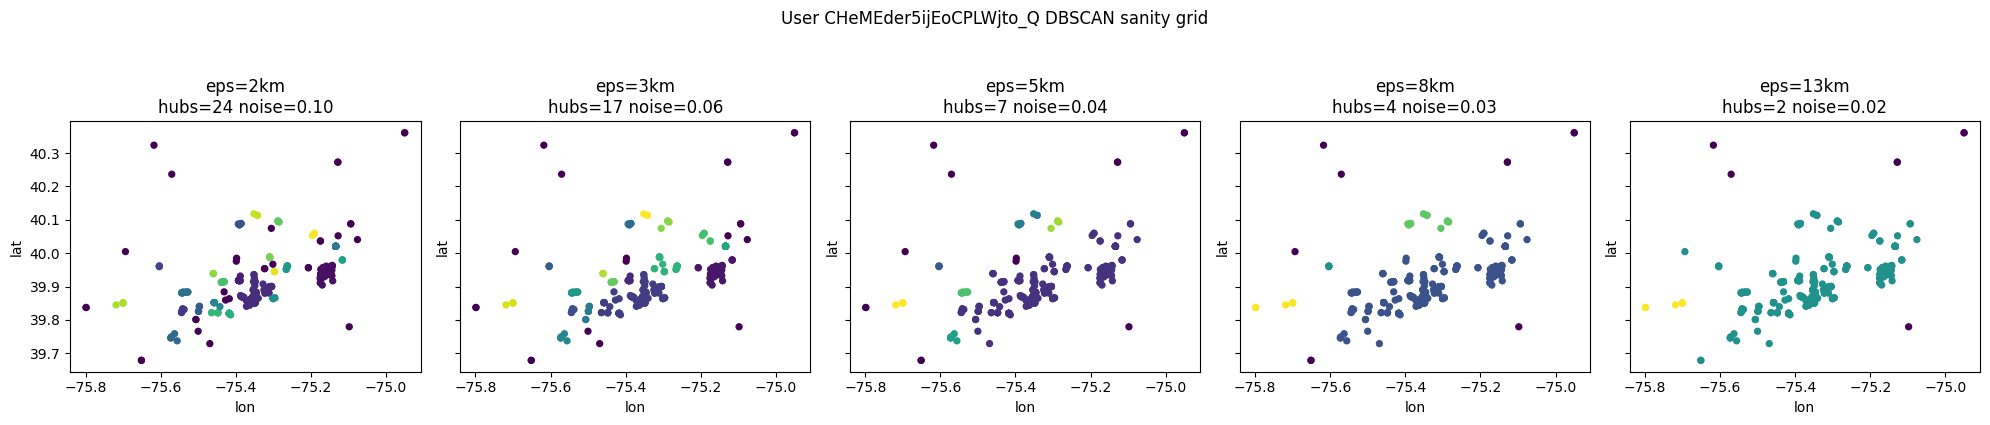

In [12]:
import matplotlib.pyplot as plt

def plot_user_eps_grid(uid, eps_list=(2,3,5,8,13), min_samples=3):
    dfu = visits[visits["user_id"] == uid].copy()

    fig, axes = plt.subplots(1, len(eps_list), figsize=(4*len(eps_list), 4), sharex=True, sharey=True)
    if len(eps_list) == 1:
        axes = [axes]

    for ax, eps in zip(axes, eps_list):
        labeled = run_dbscan_user(dfu, eps_km=eps, min_samples=min_samples)

        # scatter in lon/lat (for quick sanity). For nicer visuals you can project later.
        ax.scatter(labeled["longitude"], labeled["latitude"], s=18, c=labeled["cluster"])
        s = summarize_clusters(labeled)
        ax.set_title(f"eps={eps}km\nhubs={s['n_hubs']} noise={s['noise_ratio']:.2f}")
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")

    plt.suptitle(f"User {uid} DBSCAN sanity grid", y=1.05)
    plt.tight_layout()
    plt.show()

# example
plot_user_eps_grid(sample_users[0], eps_list=(2,3,5,8,13), min_samples=3)

In [13]:
from sklearn.cluster import DBSCAN

def dbscan_labels_latlon(dfu, eps_km=5.0, min_samples=3):
    coords = np.radians(dfu[["latitude","longitude"]].to_numpy())
    db = DBSCAN(
        eps=eps_km / EARTH_KM,      # convert km -> radians
        min_samples=min_samples,
        metric="haversine",
    ).fit(coords)
    return db.labels_

In [18]:
def haversine_km(lat1, lon1, lat2, lon2):
    a = np.radians([lat1, lon1, lat2, lon2])
    lat1, lon1, lat2, lon2 = a
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    h = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return float(2 * EARTH_KM * np.arcsin(np.sqrt(h)))

def summarize_user(dfu, eps_km=2.0, min_samples=3):
    labels = dbscan_labels_latlon(dfu, eps_km=eps_km, min_samples=min_samples)
    dfu = dfu.copy()
    dfu["cluster"] = labels

    n = len(dfu)
    noise_n = int((dfu["cluster"] == -1).sum())
    noise_ratio = noise_n / n if n else 0.0

    clusters = [c for c in sorted(dfu["cluster"].unique()) if c != -1]
    hubs = []
    for c in clusters:
        pts = dfu[dfu["cluster"] == c]
        hubs.append({
            "cluster": int(c),
            "size": int(len(pts)),
            "lat": float(pts["latitude"].mean()),
            "lon": float(pts["longitude"].mean()),
        })
    hubs.sort(key=lambda x: x["size"], reverse=True)

    n_hubs = len(hubs)
    clustered_n = sum(h["size"] for h in hubs)

    hub1_size = hubs[0]["size"] if hubs else 0
    hub2_size = hubs[1]["size"] if len(hubs) >= 2 else 0
    hub1_share = (hub1_size / clustered_n) if clustered_n else 0.0
    hub2_share = (hub2_size / clustered_n) if clustered_n else 0.0

    hub_dist_km = None
    if len(hubs) >= 2:
        hub_dist_km = haversine_km(hubs[0]["lat"], hubs[0]["lon"], hubs[1]["lat"], hubs[1]["lon"])

    # travel range: within PRIMARY hub only
    travel_range_km = None
    if hubs:
        h0 = hubs[0]
        primary_pts = dfu[dfu["cluster"] == h0["cluster"]]
        dists = primary_pts.apply(
            lambda r: haversine_km(h0["lat"], h0["lon"], r["latitude"], r["longitude"]),
            axis=1
        )
        travel_range_km = float(dists.median()) if len(dists) else None

    return {
        "user_id": dfu["user_id"].iloc[0],
        "n_visits": int(n),
        "n_hubs": int(n_hubs),
        "noise_ratio": float(noise_ratio),
        "hub1_share": float(hub1_share),
        "hub2_share": float(hub2_share),
        "hub1_size": int(hub1_size),
        "hub2_size": int(hub2_size),
        "hub_dist_km": hub_dist_km,
        "travel_range_km": travel_range_km,
    }

In [19]:
def classify_mobility(row):
    n_hubs = int(row["n_hubs"])

    hub1_share = float(row["hub1_share"]) if pd.notna(row["hub1_share"]) else 0.0
    hub2_share = float(row["hub2_share"]) if pd.notna(row["hub2_share"]) else 0.0
    hub2_size  = int(row["hub2_size"]) if pd.notna(row["hub2_size"]) else 0

    hubd = float(row["hub_dist_km"]) if pd.notna(row["hub_dist_km"]) else None

    # One-area: one hub dominates clustered points
    if n_hubs == 1 and hub1_share >= 0.60:
        return "one_area"

    # Two-area commuter (clean): exactly 2 hubs, both meaningful
    if n_hubs == 2 and hubd is not None:
        if hub2_size >= 5 and hub1_share >= 0.35 and hub2_share >= 0.20 and hubd <= 100:
            return "two_area"

    return "explorer"

def build_population_summary(visits, eps_km=5.0, min_samples=3):
    rows = []
    for uid, dfu in visits.groupby("user_id"):
        if len(dfu) < 5:   # your min_visits
            continue
        rows.append(summarize_user(dfu, eps_km=eps_km, min_samples=min_samples))

    pop = pd.DataFrame(rows)
    pop["type"] = pop.apply(classify_mobility, axis=1)

    # % one-area / two-area
    one_pct = float((pop["type"] == "one_area").mean() * 100)
    two_pct = float((pop["type"] == "two_area").mean() * 100)

    # average hub distance among two-area users
    two = pop[(pop["type"] == "two_area") & pop["hub_dist_km"].notna()]
    avg_hub_dist = float(two["hub_dist_km"].median()) if len(two) else None

    # typical travel range (median over all users)
    typical_range = float(pop["travel_range_km"].median())

    return pop, {
        "one_area_pct": one_pct,
        "two_area_pct": two_pct,
        "avg_hub_distance_km": avg_hub_dist,
        "typical_travel_range_km": typical_range,
        "eps_km": eps_km,
        "min_samples": min_samples,
        "n_users": int(len(pop)),
    }

pop, summary = build_population_summary(visits, eps_km=5.0, min_samples=3)
summary


{'one_area_pct': 67.04055220017257,
 'two_area_pct': 2.9335634167385676,
 'avg_hub_distance_km': 13.921671070619169,
 'typical_travel_range_km': 1.4803270247448035,
 'eps_km': 5.0,
 'min_samples': 3,
 'n_users': 1159}

In [20]:
import json, os

os.makedirs("export_ui_data", exist_ok=True)

with open("export_ui_data/mobility_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

# optional: export per-user table (for deep dive / filters)
pop.to_csv("export_ui_data/user_mobility_table.csv", index=False)

print("Wrote:")
print(" - export_ui_data/mobility_summary.json")
print(" - export_ui_data/user_mobility_table.csv")


Wrote:
 - export_ui_data/mobility_summary.json
 - export_ui_data/user_mobility_table.csv
